In [1]:
import os
import sys
sys.path.append(os.path.abspath('/root/performances_prediction_of_asset_allocations'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Load data

In [2]:
X_train = pd.read_csv('../data/raw/X_train.csv',index_col='ROW_ID')
y_train = pd.read_csv('../data/raw/y_train.csv',index_col='ROW_ID')

In [23]:
X_train.iloc[:,2:22].head()

,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,RET_10,RET_9,RET_8,RET_7,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1
0,0.005324,-0.000261,0.000329,0.002983,0.003300,-0.003082,-0.004202,0.001252,-0.005408,-0.003320,-0.003205,-0.007136,0.002179,0.016005,-0.002136,-0.009742,0.000668,0.002723,-0.000697,-0.003688
1,0.002317,-0.001279,-0.002198,0.001009,0.001403,-0.001530,-0.000028,0.005642,-0.004470,0.001235,0.001608,0.000278,-0.002852,-0.002865,-0.006106,-0.000614,0.001078,-0.002642,0.001525,0.001196
2,0.001999,-0.003056,-0.000122,-0.004058,-0.001924,0.003454,-0.000395,-0.005690,-0.005533,0.001531,-0.001089,-0.002496,-0.000653,0.002437,0.002072,0.002690,0.000157,0.005016,-0.002387,0.000106
3,-0.004243,0.001364,0.001433,-0.003110,0.001214,-0.000306,-0.000181,0.000875,-0.003777,-0.000837,-0.000209,0.000260,0.001590,-0.001345,0.000092,-0.006910,0.002610,-0.004125,0.000935,0.001871
4,-0.003125,0.004081,-0.004851,0.001456,0.000335,-0.000776,0.001399,-0.000787,-0.000223,0.000505,-0.002661,0.000469,-0.002674,-0.004050,0.000057,-0.001604,-0.000268,-0.000538,-0.000408,-0.000397


In [4]:
# --- Complete rows ---
total = len(X_train)
complete = X_train.dropna().shape[0]
incomplete = total - complete

print(f"Total rows:                  {total:,}")
print(f"Rows with NO missing values: {complete:,}  ({100*complete/total:.2f}%)")
print(f"Rows with missing values:    {incomplete:,}  ({100*incomplete/total:.2f}%)")

# --- Which columns have missings? ---
miss = X_train.isnull().sum()
miss_pct = 100 * X_train.isnull().mean()
miss_df = pd.DataFrame({'count': miss, 'pct': miss_pct})
print("\nColumns with missing values:")
print(miss_df[miss_df['count'] > 0].sort_values('pct', ascending=False))

Total rows:                  527,073
Rows with NO missing values: 136,909  (25.98%)
Rows with missing values:    390,164  (74.02%)

Columns with missing values:
                        count        pct
SIGNED_VOLUME_1        387506  73.520366
SIGNED_VOLUME_20         8498   1.612300
MEDIAN_DAILY_TURNOVER    3638   0.690227
SIGNED_VOLUME_19         3002   0.569561
SIGNED_VOLUME_18          859   0.162976
SIGNED_VOLUME_17           58   0.011004
RET_20                     58   0.011004
RET_19                     50   0.009486
SIGNED_VOLUME_16           50   0.009486
SIGNED_VOLUME_15           42   0.007969
RET_18                     42   0.007969
SIGNED_VOLUME_14           34   0.006451
RET_17                     34   0.006451
RET_16                     26   0.004933
SIGNED_VOLUME_13           26   0.004933
SIGNED_VOLUME_12           18   0.003415
RET_15                     18   0.003415
RET_14                     13   0.002466
SIGNED_VOLUME_11           13   0.002466
SIGNED_VOLUME_10   

In [ ]:
# Drop NA rows for now
rows_not_na = X_train.notna().all(axis=1)
X_train = X_train[rows_not_na].copy()
y_train = y_train[rows_not_na].copy()
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)

### Plot Returns and Signed Volumes per Group

In [10]:
RET_COLS = [f'RET_{i}' for i in range(20, 0, -1)]       # t-20 ... t-1
VOL_COLS = [f'SIGNED_VOLUME_{i}' for i in range(20, 0, -1)]
X_LABELS = [f't-{i}' for i in range(20, 0, -1)]

In [27]:
g = 4
np.mean(np.sign(X_train[X_train.GROUP==g].iloc[:,3:22] - X_train[X_train.GROUP==g].iloc[:,2:21]).prod()==1)

np.float64(0.1)

In [ ]:
n = 10
group_id = 4
group_df = X_train[X_train['GROUP'] == group_id]

# One representative row per allocation: pick the most recent date
representatives = (
    group_df.sort_values('TS')
            .groupby('ALLOCATION')
            .last()
            .reset_index()
)

n_available = len(representatives)
if n_available < n:
    print(f"Warning: only {n_available} allocations in Group {group_id}, plotting all.")
    n = n_available

sample = representatives.sample(n=n, random_state=42)

sns.set_style('whitegrid')
fig, axes = plt.subplots(
    nrows=n, ncols=2,
    figsize=(16, 2.8 * n),
    sharex=True
)
if n == 1:
    axes = [axes]  # ensure iterable

colors_ret = ['#2ecc71', '#e74c3c']   # green / red per bar sign
color_vol   = '#5b8dee'

fig.suptitle(
    f'Group {group_id} — Returns & Signed Volume (past 20 days)\n'
    f'{n} sampled allocations',
    fontsize=14, fontweight='bold', y=1.01
)

for row_idx, (_, row) in enumerate(sample.iterrows()):
    alloc_name = row['ALLOCATION']
    rets = row[RET_COLS].values.astype(float)
    vols = row[VOL_COLS].values.astype(float)

    # --- Returns (left column) ---
    ax_ret = axes[row_idx][0]
    bar_colors = [colors_ret[0] if r >= 0 else colors_ret[1] for r in rets]
    ax_ret.bar(range(20), rets, color=bar_colors, alpha=0.85, width=0.7)
    ax_ret.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax_ret.set_ylabel(alloc_name, fontsize=9, rotation=0, labelpad=90, va='center')
    ax_ret.yaxis.set_label_position('left')
    ax_ret.tick_params(axis='y', labelsize=8)
    if row_idx == 0:
        ax_ret.set_title('Daily Return', fontsize=11)
    ax_ret.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.2f}%'))

    # --- Signed Volume (right column) ---
    ax_vol = axes[row_idx][1]
    ax_vol.plot(range(20), vols, color=color_vol, linewidth=1.6, marker='o', markersize=3)
    ax_vol.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax_vol.fill_between(range(20), vols, 0,
                        where=(vols >= 0), alpha=0.15, color=colors_ret[0])
    ax_vol.fill_between(range(20), vols, 0,
                        where=(vols < 0),  alpha=0.15, color=colors_ret[1])
    ax_vol.tick_params(axis='y', labelsize=8)
    if row_idx == 0:
        ax_vol.set_title('Signed Volume', fontsize=11)

# Shared x-axis labels
for col in range(2):
    axes[-1][col].set_xticks(range(20))
    axes[-1][col].set_xticklabels(X_LABELS, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

### Plot Returns and Signed Volumes for an allocation at different Timestamps

In [7]:
X_train.ALLOCATION.unique()

<StringArray>
[ 'ALLOCATION_06', 'ALLOCATION_111', 'ALLOCATION_113', 'ALLOCATION_115',
 'ALLOCATION_117', 'ALLOCATION_118', 'ALLOCATION_152', 'ALLOCATION_156',
 'ALLOCATION_168', 'ALLOCATION_172',
 ...
  'ALLOCATION_94',  'ALLOCATION_95',  'ALLOCATION_98',  'ALLOCATION_99',
 'ALLOCATION_207',  'ALLOCATION_74',  'ALLOCATION_05',  'ALLOCATION_24',
  'ALLOCATION_14',  'ALLOCATION_46']
Length: 278, dtype: str

In [ ]:
n = 5
allocation_id = 'ALLOCATION_118'
alloc_df = X_train[X_train['ALLOCATION'] == allocation_id]

n_available = len(alloc_df)

if n_available < n:
    print(f"Warning: only {n_available} dates available for {allocation_id}, plotting all.")
    n = n_available

sample = alloc_df.sample(n=n, random_state=42).sort_values('TS')

sns.set_style('whitegrid')
fig, axes = plt.subplots(
    nrows=n, ncols=2,
    figsize=(16, 2.8 * n),
    sharex=True
)
if n == 1:
    axes = [axes]

colors_ret = ['#2ecc71', '#e74c3c']
color_vol  = '#5b8dee'

group_id = sample['GROUP'].iloc[0]
fig.suptitle(
    f'{allocation_id} (Group {group_id}) — Returns & Signed Volume across dates\n'
    f'{n} sampled timestamps',
    fontsize=14, fontweight='bold', y=1.01
)

for row_idx, (_, row) in enumerate(sample.iterrows()):
    date_label = row['TS']
    rets = row[RET_COLS].values.astype(float)
    vols = row[VOL_COLS].values.astype(float)

    # --- Returns (left) ---
    ax_ret = axes[row_idx][0]
    bar_colors = [colors_ret[0] if r >= 0 else colors_ret[1] for r in rets]
    ax_ret.bar(range(20), rets, color=bar_colors, alpha=0.85, width=0.7)
    ax_ret.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax_ret.set_ylabel(date_label, fontsize=9, rotation=0, labelpad=70, va='center')
    ax_ret.tick_params(axis='y', labelsize=8)
    ax_ret.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.2f}%'))
    if row_idx == 0:
        ax_ret.set_title('Daily Return', fontsize=11)

    # --- Signed Volume (right) ---
    ax_vol = axes[row_idx][1]
    ax_vol.plot(range(20), vols, color=color_vol, linewidth=1.6, marker='o', markersize=3)
    ax_vol.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax_vol.fill_between(range(20), vols, 0,
                        where=(vols >= 0), alpha=0.15, color=colors_ret[0])
    ax_vol.fill_between(range(20), vols, 0,
                        where=(vols < 0),  alpha=0.15, color=colors_ret[1])
    ax_vol.tick_params(axis='y', labelsize=8)
    if row_idx == 0:
        ax_vol.set_title('Signed Volume', fontsize=11)

for col in range(2):
    axes[-1][col].set_xticks(range(20))
    axes[-1][col].set_xticklabels(X_LABELS, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

### Variability of TURNOVER (MEDIAN) for each group

In [ ]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

groups = sorted(X_train['GROUP'].unique())
data_by_group = [X_train[X_train['GROUP'] == g]['MEDIAN_DAILY_TURNOVER'].values for g in groups]
colors = ['#5b8dee', '#2ecc71', '#e74c3c', '#f39c12']

bp = ax.boxplot(
    data_by_group,
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, alpha=0.3, linestyle='none')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Overlay individual points (jittered) for density feel
# for i, (group_data, color) in enumerate(zip(data_by_group, colors), start=1):
#     jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(group_data))
#     ax.scatter(i + jitter, group_data, alpha=0.15, s=8, color=color, zorder=2)

ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels([f'Group {g}' for g in groups], fontsize=11)
ax.set_ylabel('Median Daily Turnover', fontsize=11)
ax.set_title('Variability of Median Daily Turnover by Group', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotation: median value above each box
for i, group_data in enumerate(data_by_group, start=1):
    median_val = np.median(group_data)
    ax.text(i, ax.get_ylim()[1] * 0.98, f'med={median_val:.4f}',
            ha='center', va='top', fontsize=8.5, color='#333333')

plt.tight_layout()
plt.show()

In [ ]:
n_allocs = 5
groups = sorted(X_train['GROUP'].unique())
colors = {1: '#5b8dee', 2: '#2ecc71', 3: '#e74c3c', 4: '#f39c12'}

fig, axes = plt.subplots(
    nrows=len(groups), ncols=1,
    figsize=(14, 4.5 * len(groups))
)
if len(groups) == 1:
    axes = [axes]

for ax, group_id in zip(axes, groups):
    group_df = X_train[X_train['GROUP'] == group_id]
    available_allocs = group_df['ALLOCATION'].unique()

    rng = np.random.default_rng(42)
    n = min(n_allocs, len(available_allocs))
    sampled_allocs = rng.choice(available_allocs, size=n, replace=False)
    sampled_allocs = sorted(sampled_allocs)

    data = [
        group_df[group_df['ALLOCATION'] == alloc]['MEDIAN_DAILY_TURNOVER'].values
        for alloc in sampled_allocs
    ]
    color = colors[group_id]

    vp = ax.violinplot(data, positions=range(1, n + 1), showmedians=True,
                        showextrema=True, widths=0.6)

    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.6)
        body.set_edgecolor('black')
        body.set_linewidth(1.2)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)
    vp['cmins'].set_color(color)
    vp['cmaxes'].set_color(color)
    vp['cbars'].set_color(color)

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(
        [a.replace('ALLOCATION_', 'A_') for a in sampled_allocs],
        fontsize=9
    )
    ax.set_ylabel('Median Daily Turnover', fontsize=9)
    ax.set_title(f'Group {group_id}', fontsize=11, fontweight='bold', loc='left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Annotate n observations per violin
    for i, (alloc_data, pos) in enumerate(zip(data, range(1, n + 1))):
        ax.text(pos, ax.get_ylim()[1], f'n={len(alloc_data)}',
                ha='center', va='bottom', fontsize=8, color='#555555')

fig.suptitle(
    'Distribution of Median Daily Turnover by Allocation within each Group\n'
    f'({n_allocs} sampled allocations per group, across all timestamps)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

### Return variations VS Signed Volume variation

In [ ]:
n = 10
group_id = 2
group_df = X_train[X_train['GROUP'] == group_id]
available_allocs = group_df['ALLOCATION'].unique()

rng = np.random.default_rng(42)
n = min(n, len(available_allocs))
sampled_allocs = rng.choice(available_allocs, size=n, replace=False)

# One representative row per allocation: most recent timestamp
representatives = (
    group_df[group_df['ALLOCATION'].isin(sampled_allocs)]
    .sort_values('TS')
    .groupby('ALLOCATION')
    .last()
    .reset_index()
)

sns.set_style('white')
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(14, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

color_same = '#2ecc71'
color_diff = '#e74c3c'
color_undef = '#aaaaaa'

# Intervals: t-20→t-19, t-19→t-18, ..., t-2→t-1  (19 intervals)
interval_labels = [f't-{20-i}→t-{19-i}' for i in range(19)]

for ax, (_, row) in zip(axes, representatives.iterrows()):
    rets = row[RET_COLS].values.astype(float)    # index 0 = t-20, 19 = t-1
    vols = row[VOL_COLS].values.astype(float)

    delta_ret = np.diff(rets)          # shape (19,)
    delta_vol = np.diff(vols)

    # Compute sign of ratio: same sign → +1, opposite → -1, undefined → 0
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(delta_vol == 0, np.nan, delta_ret / delta_vol)

    signs = np.where(
        np.isnan(ratio), 0,
        np.where(ratio > 0, 1, np.where(ratio < 0, -1, 0))
    )

    bar_colors = [
        color_same if s == 1 else color_diff if s == -1 else color_undef
        for s in signs
    ]

    ax.bar(range(19), signs, color=bar_colors, alpha=0.85, width=0.7)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['opposite', 'undef', 'same'], fontsize=8)
    ax.set_ylabel(row['ALLOCATION'].replace('ALLOCATION_', 'A_'),
                    fontsize=9, rotation=0, labelpad=75, va='center')

    # Annotate counts
    n_same = (signs == 1).sum()
    n_diff = (signs == -1).sum()
    n_undef = (signs == 0).sum()
    # ax.text(0.99, 0.88,
            # f'same={n_same}  opp={n_diff}  undef={n_undef}',
            # transform=ax.transAxes, ha='right', va='top',
            # fontsize=8, color='#444444')

axes[-1].set_xticks(range(19))
axes[-1].set_xticklabels(interval_labels, rotation=45, ha='right', fontsize=8)

fig.suptitle(
    f'Group {group_id} — Co-direction of ΔReturn & ΔSigned Volume\n'
    f'{n} sampled allocations (most recent timestamp)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

In [ ]:
n = 5
allocation_id = 'ALLOCATION_06'
alloc_df = X_train[X_train['ALLOCATION'] == allocation_id]

n_available = len(alloc_df)
if n_available < n:
    print(f"Warning: only {n_available} timestamps available for {allocation_id}, plotting all.")
    n = n_available

sample = alloc_df.sample(n=n, random_state=42).sort_values('TS')

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(14, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

color_same  = '#2ecc71'
color_diff  = '#e74c3c'
color_undef = '#aaaaaa'
interval_labels = [f't-{20-i}→t-{19-i}' for i in range(19)]

group_id = sample['GROUP'].iloc[0]

for ax, (_, row) in zip(axes, sample.iterrows()):
    rets = row[RET_COLS].values.astype(float)
    vols = row[VOL_COLS].values.astype(float)

    delta_ret = np.diff(rets)
    delta_vol = np.diff(vols)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(delta_vol == 0, np.nan, delta_ret / delta_vol)

    signs = np.where(
        np.isnan(ratio), 0,
        np.where(ratio > 0, 1, np.where(ratio < 0, -1, 0))
    )

    bar_colors = [
        color_same if s == 1 else color_diff if s == -1 else color_undef
        for s in signs
    ]

    ax.bar(range(19), signs, color=bar_colors, alpha=0.85, width=0.7)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['opposite', 'undef', 'same'], fontsize=8)
    ax.set_ylabel(row['TS'], fontsize=9, rotation=0, labelpad=75, va='center')

    n_same  = (signs ==  1).sum()
    n_diff  = (signs == -1).sum()
    n_undef = (signs ==  0).sum()
    # ax.text(0.99, 0.88,
    #         f'same={n_same}  opp={n_diff}  undef={n_undef}',
    #         transform=ax.transAxes, ha='right', va='top',
    #         fontsize=8, color='#444444')

axes[-1].set_xticks(range(19))
axes[-1].set_xticklabels(interval_labels, rotation=45, ha='right', fontsize=8)

fig.suptitle(
    f'{allocation_id} (Group {group_id}) — Co-direction of ΔReturn & ΔSigned Volume\n'
    f'{n} sampled timestamps',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()


### Autocorrelation between returns signals

In [37]:
s1 = X_train.loc[5,RET_COLS].to_numpy()
s2 = X_train.loc[6,RET_COLS].to_numpy()

np.correlate(s1, s2, mode='valid')

array([5.97930146e-05])

In [38]:
def compute_autocorr(signal, normalize=True):
    """Normalized autocorrelation of a 1D signal using np.correlate(mode='same')."""
    s = signal - signal.mean()
    v = signal.var()
    if normalize:
        ac = np.correlate(s, s, mode='same')
        ac = ac / v
    else:
        ac = np.correlate(signal, signal, mode='same')
    return ac

def compute_crosscorr(signal1, signal2, normalize=True):
    """Normalized cross-correlation of two 1D signals using np.correlate(mode='same')."""
    s1 = signal1 - signal1.mean()
    s2 = signal2 - signal2.mean()
    v1 = signal1.var()
    v2 = signal2.var()
    if normalize:
        cc = np.correlate(s1, s2, mode='same')
        cc = cc / (np.sqrt(v1 * v2))
    else:
        cc = np.correlate(signal1, signal2, mode='same')
    return cc

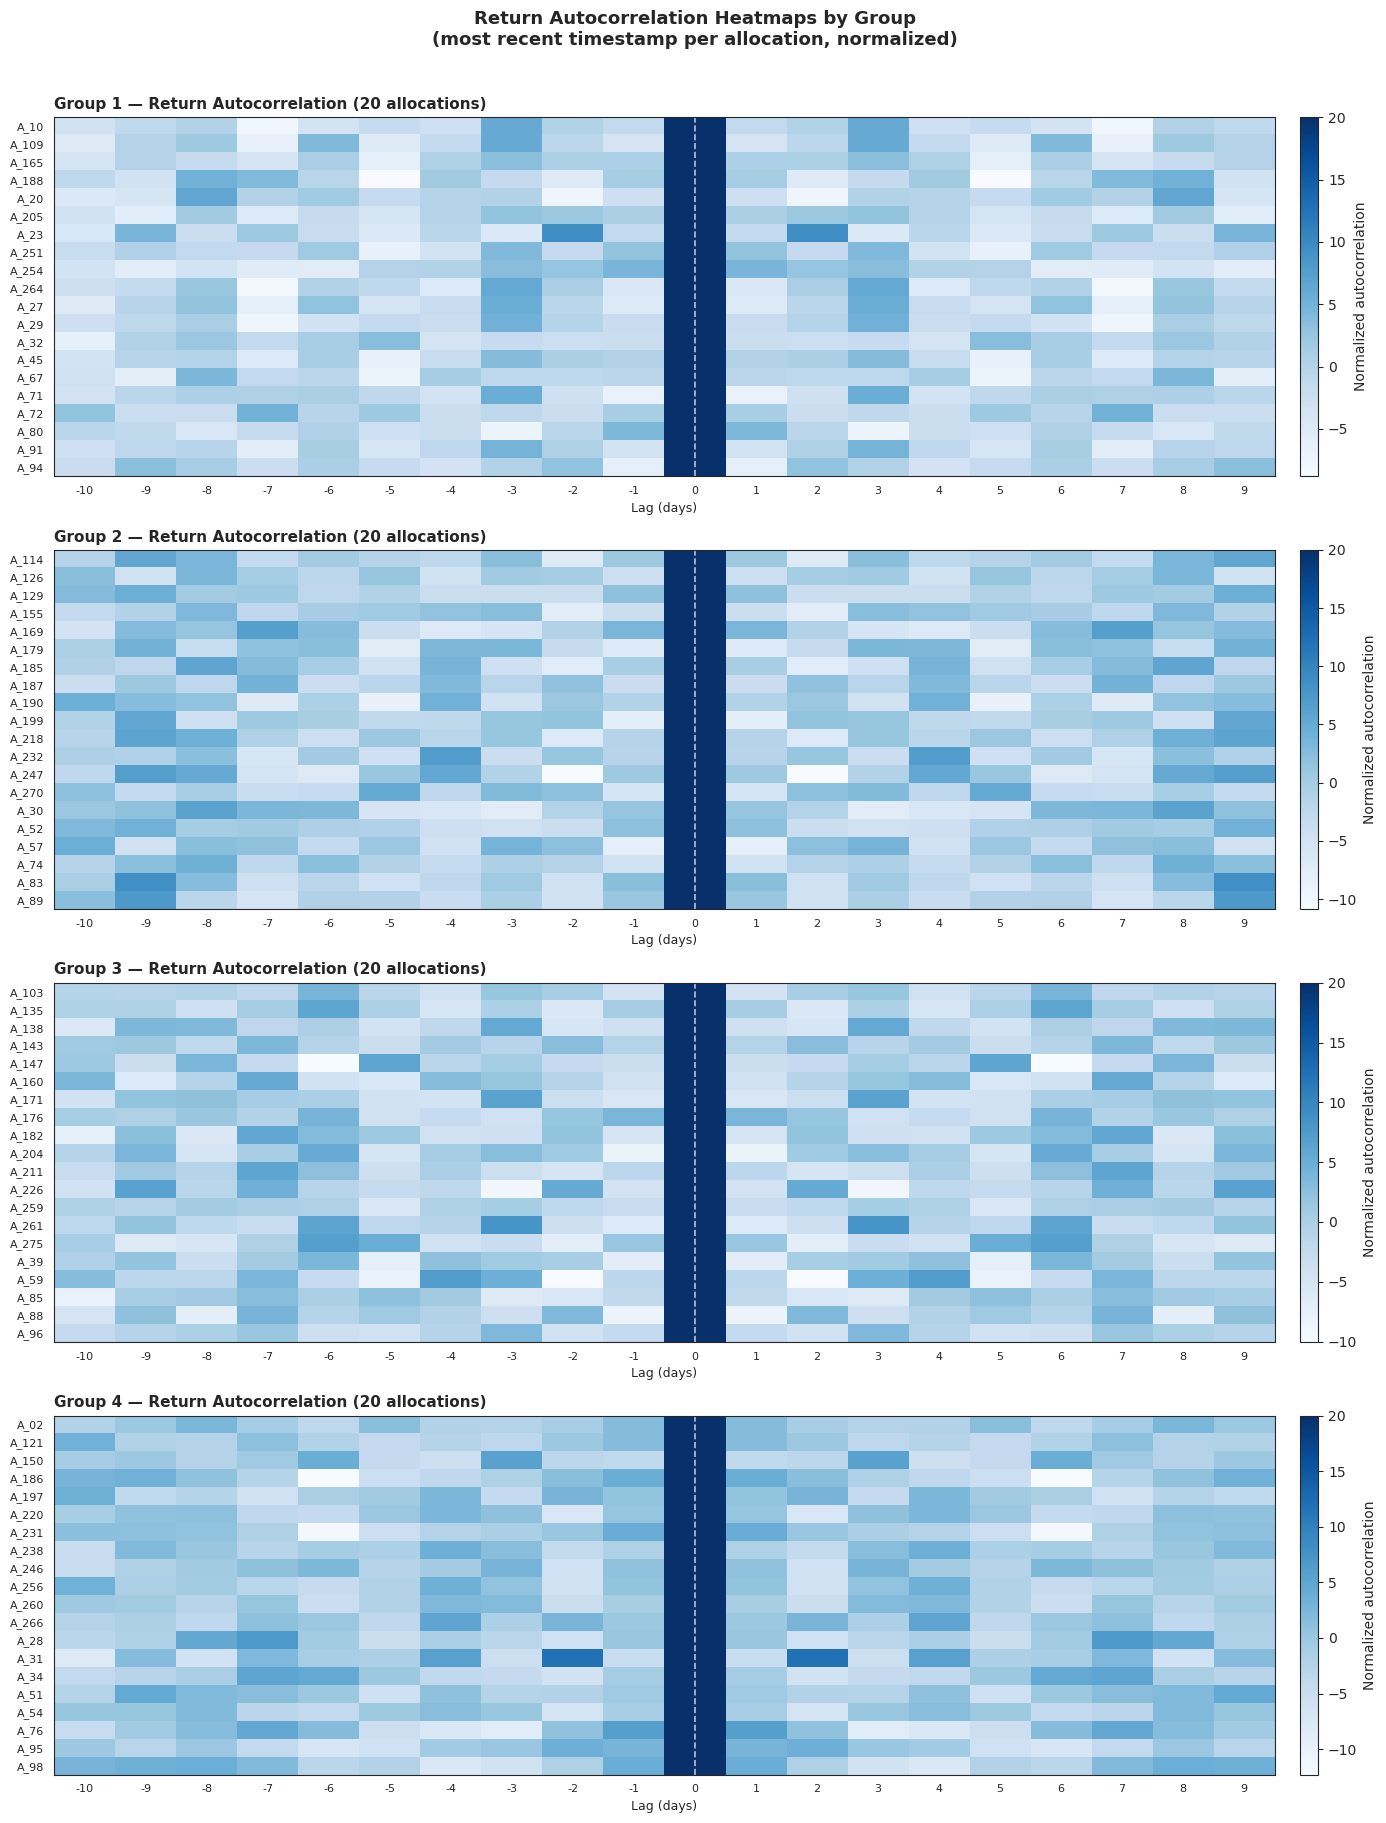

In [40]:
n = 20
groups  = sorted(X_train['GROUP'].unique())
colors  = {1: 'Blues', 2: 'Greens', 3: 'Reds', 4: 'Oranges'}
rng     = np.random.default_rng(42)

sns.set_style('white')
fig, axes = plt.subplots(
    nrows=len(groups), ncols=1,
    figsize=(14, 4.5 * len(groups))
)
if len(groups) == 1:
    axes = [axes]

for ax, group_id in zip(axes, groups):
    group_df       = X_train[X_train['GROUP'] == group_id]
    available      = group_df['ALLOCATION'].unique()
    n_sample       = min(n, len(available))
    sampled_allocs = rng.choice(available, size=n_sample, replace=False)

    # Most recent timestamp per allocation
    representatives = (
        group_df[group_df['ALLOCATION'].isin(sampled_allocs)]
        .sort_values('TS')
        .groupby('ALLOCATION')
        .last()
        .reset_index()
    )

    # Build heatmap matrix: (n_sample x 20)
    autocorr_matrix = []
    alloc_labels    = []

    for _, row in representatives.iterrows():
        rets = row[RET_COLS].values.astype(float)
        ac   = compute_autocorr(rets, normalize=True)   # length 20 (mode='same' preserves length)
        autocorr_matrix.append(ac)
        alloc_labels.append(row['ALLOCATION'].replace('ALLOCATION_', 'A_'))

    autocorr_matrix = np.array(autocorr_matrix)   # shape (n_sample, 20)

    # Lag labels: mode='same' centers at lag 0, so lags go from -(N//2) to +(N//2)
    N        = autocorr_matrix.shape[1]
    lag_labels = [str(l) for l in range(-(N // 2), N // 2 + (N % 2))]

    im = ax.imshow(
        autocorr_matrix,
        aspect='auto',
        cmap='Blues',
        # vmin=-1, vmax=1,
        interpolation='nearest'
    )

    ax.set_yticks(range(n_sample))
    ax.set_yticklabels(alloc_labels, fontsize=8)
    ax.set_xticks(range(N))
    ax.set_xticklabels(lag_labels, fontsize=8)
    ax.set_xlabel('Lag (days)', fontsize=9)
    ax.set_title(f'Group {group_id} — Return Autocorrelation ({n_sample} allocations)',
                    fontsize=11, fontweight='bold', loc='left')

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Normalized autocorrelation')

    # Vertical line at lag 0
    ax.axvline(x=N // 2, color='white', linewidth=1.2, linestyle='--', alpha=0.7)

fig.suptitle(
    'Return Autocorrelation Heatmaps by Group\n'
    '(most recent timestamp per allocation, normalized)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

In [45]:
X_train.ALLOCATION.value_counts()

ALLOCATION
ALLOCATION_115    2439
ALLOCATION_118    2439
ALLOCATION_152    2439
ALLOCATION_156    2439
ALLOCATION_70     2439
                  ... 
ALLOCATION_41      256
ALLOCATION_05      229
ALLOCATION_24      217
ALLOCATION_14        1
ALLOCATION_46        1
Name: count, Length: 278, dtype: int64

In [48]:
X_train_alloc = X_train[X_train.ALLOCATION == 'ALLOCATION_24'].copy()
X_train_alloc.reset_index(drop=True, inplace=True)

s1 = X_train_alloc.loc[0,RET_COLS].to_numpy()
s2 = X_train_alloc.loc[1,RET_COLS].to_numpy()
compute_crosscorr(s1, s2, normalize=True)

array([-3.75385183, -2.52221425,  2.60869568,  0.09503194,  3.83982742,
        3.54264294,  2.2533547 , -6.24416557, -4.42621146,  1.0076649 ,
        1.39578178, -2.9305044 ,  2.15792686,  2.40826641,  4.04545827,
       -4.77635544, -2.5826579 ,  3.63140296,  1.81697047, -0.88247567])